In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("Environment ready")

pandas: 2.3.3
scikit-learn: 1.7.2
Environment ready


## 1. Online Shoppers Purchasing Intention — Data Quality Check

In [3]:
from pathlib import Path

downloads = Path.home() / "Downloads"
shoppers_path = downloads / "online_shoppers_intention.csv"

shoppers = pd.read_csv(shoppers_path)

print("Dataset shape:", shoppers.shape)
display(shoppers.head())

Dataset shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:
print("Rows and columns:", shoppers.shape)
print("\nMissing values:")
display(shoppers.isna().sum())

print("Duplicate rows:", shoppers.duplicated().sum())

print("\nTarget counts:")
display(shoppers["Revenue"].value_counts())

print("\nTarget percentages:")
display(
    shoppers["Revenue"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Rows and columns: (12330, 18)

Missing values:


Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Duplicate rows: 125

Target counts:


Revenue
False    10422
True      1908
Name: count, dtype: int64


Target percentages:


Revenue
False    84.53
True     15.47
Name: proportion, dtype: float64

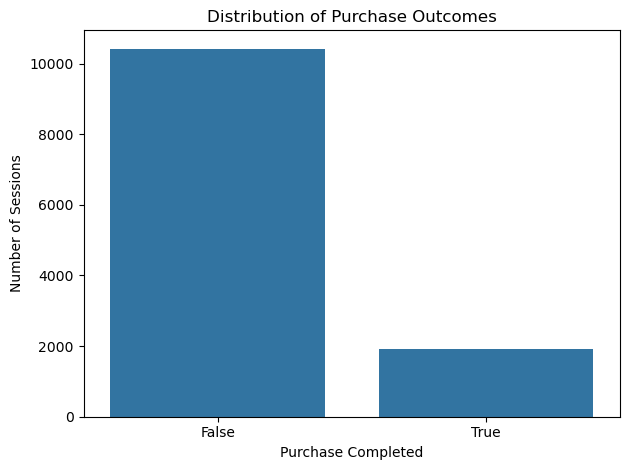

In [6]:
ax = sns.countplot(data=shoppers, x="Revenue")

ax.set_title("Distribution of Purchase Outcomes")
ax.set_xlabel("Purchase Completed")
ax.set_ylabel("Number of Sessions")

plt.tight_layout()
plt.show()

## 2. Purchase Intention Classification — Logistic Regression

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

X = shoppers.drop(columns="Revenue")
y = shoppers["Revenue"].astype(int)

categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

numeric_features = [
    column for column in X.columns
    if column not in categorical_features
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
Categorical features: ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Training purchase rate:", y_train.mean().round(4))
print("Test purchase rate:", y_test.mean().round(4))

Training shape: (9864, 17)
Test shape: (2466, 17)
Training purchase rate: 0.1547
Test purchase rate: 0.1549


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

print("Model training complete")

Model training complete


In [10]:
y_pred = logistic_model.predict(X_test)
y_probability = logistic_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=3))

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, y_probability), 3)
)

print(
    "PR-AUC:",
    round(average_precision_score(y_test, y_probability), 3)
)

confusion = confusion_matrix(y_test, y_pred)
display(
    pd.DataFrame(
        confusion,
        index=["Actual: No Purchase", "Actual: Purchase"],
        columns=["Predicted: No Purchase", "Predicted: Purchase"]
    )
)

              precision    recall  f1-score   support

           0      0.948     0.859     0.901      2084
           1      0.491     0.743     0.592       382

    accuracy                          0.841      2466
   macro avg      0.720     0.801     0.746      2466
weighted avg      0.877     0.841     0.853      2466

ROC-AUC: 0.893
PR-AUC: 0.622


,Predicted: No Purchase,Predicted: Purchase
Actual: No Purchase,1790,294
Actual: Purchase,98,284


## 3. Online Retail II — Customer Segmentation

In [11]:
from zipfile import ZipFile
from io import BytesIO

retail_zip_path = downloads / "online+retail+ii.zip"

with ZipFile(retail_zip_path) as archive:
    excel_bytes = archive.read("online_retail_II.xlsx")

retail_2009_2010 = pd.read_excel(
    BytesIO(excel_bytes),
    sheet_name="Year 2009-2010"
)

retail_2010_2011 = pd.read_excel(
    BytesIO(excel_bytes),
    sheet_name="Year 2010-2011"
)

retail = pd.concat(
    [retail_2009_2010, retail_2010_2011],
    ignore_index=True
)

print("Combined shape:", retail.shape)
display(retail.head())

Combined shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [12]:
print("Missing values:")
display(retail.isna().sum())

print("Duplicate rows:", retail.duplicated().sum())

cancelled = retail["Invoice"].astype(str).str.startswith("C")

print("Cancelled rows:", cancelled.sum())
print("Negative quantities:", (retail["Quantity"] < 0).sum())
print("Non-positive prices:", (retail["Price"] <= 0).sum())
print("Unique customers:", retail["Customer ID"].nunique())

Missing values:


Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Duplicate rows: 34335
Cancelled rows: 19494
Negative quantities: 22950
Non-positive prices: 6207
Unique customers: 5942


### 3.1 Cleaning completed transactions and constructing RFM features

In [13]:
retail_clean = retail.drop_duplicates().copy()

# Customer ID is required to connect transactions to customers
retail_clean = retail_clean.dropna(subset=["Customer ID"]).copy()

retail_clean["Invoice"] = retail_clean["Invoice"].astype(str)
retail_clean["Customer ID"] = retail_clean["Customer ID"].astype(int)

# Retain completed purchases for RFM segmentation
completed_orders = retail_clean[
    (~retail_clean["Invoice"].str.startswith("C")) &
    (retail_clean["Quantity"] > 0) &
    (retail_clean["Price"] > 0)
].copy()

completed_orders["TotalValue"] = (
    completed_orders["Quantity"] * completed_orders["Price"]
)

print("Original rows:", len(retail))
print("After removing duplicates:", len(retail_clean))
print("Completed purchase rows:", len(completed_orders))
print("Customers retained:", completed_orders["Customer ID"].nunique())

Original rows: 1067371
After removing duplicates: 797885
Completed purchase rows: 779425
Customers retained: 5878


In [14]:
snapshot_date = completed_orders["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    completed_orders
    .groupby("Customer ID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda dates: (snapshot_date - dates.max()).days
        ),
        Frequency=("Invoice", "nunique"),
        Monetary=("TotalValue", "sum")
    )
    .reset_index()
)

print("RFM shape:", rfm.shape)
display(rfm.head())
display(rfm[["Recency", "Frequency", "Monetary"]].describe())

RFM shape: (5878, 4)


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


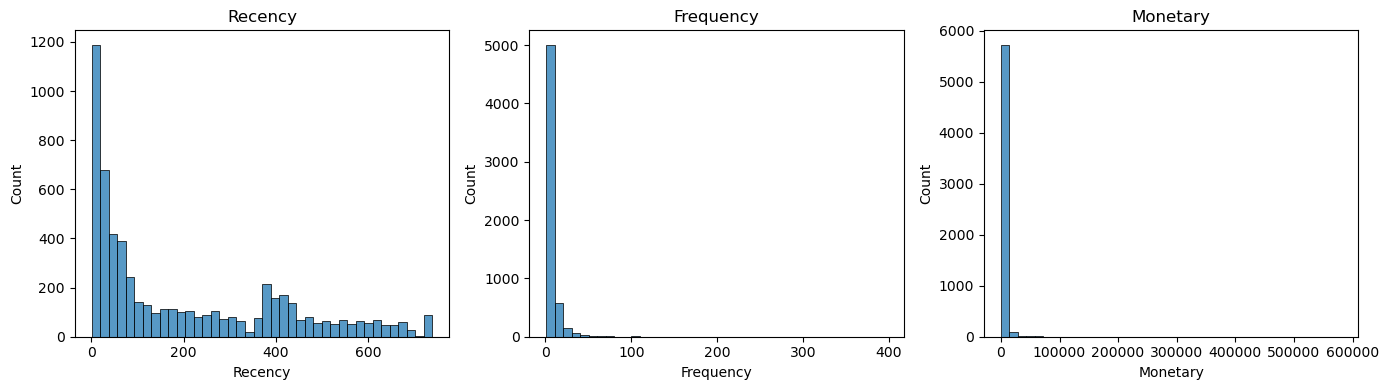

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for column, axis in zip(
    ["Recency", "Frequency", "Monetary"],
    axes
):
    sns.histplot(rfm[column], bins=40, ax=axis)
    axis.set_title(column)

plt.tight_layout()
plt.show()

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

rfm_features = rfm[["Recency", "Frequency", "Monetary"]].copy()

rfm_log = np.log1p(rfm_features)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

print("Scaled shape:", rfm_scaled.shape)

Scaled shape: (5878, 3)


In [17]:
cluster_results = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(rfm_scaled)

    cluster_results.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(rfm_scaled, labels),
        "Davies_Bouldin": davies_bouldin_score(rfm_scaled, labels)
    })

cluster_results = pd.DataFrame(cluster_results)

display(
    cluster_results.round({
        "Inertia": 1,
        "Silhouette": 3,
        "Davies_Bouldin": 3
    })
)

,K,Inertia,Silhouette,Davies_Bouldin
0,2,8589.0,0.439,0.873
1,3,6354.3,0.348,1.036
2,4,4921.2,0.365,0.930
3,5,4099.1,0.342,0.950
4,6,3554.7,0.335,0.964
5,7,3194.5,0.307,0.981
6,8,2902.4,0.303,0.986


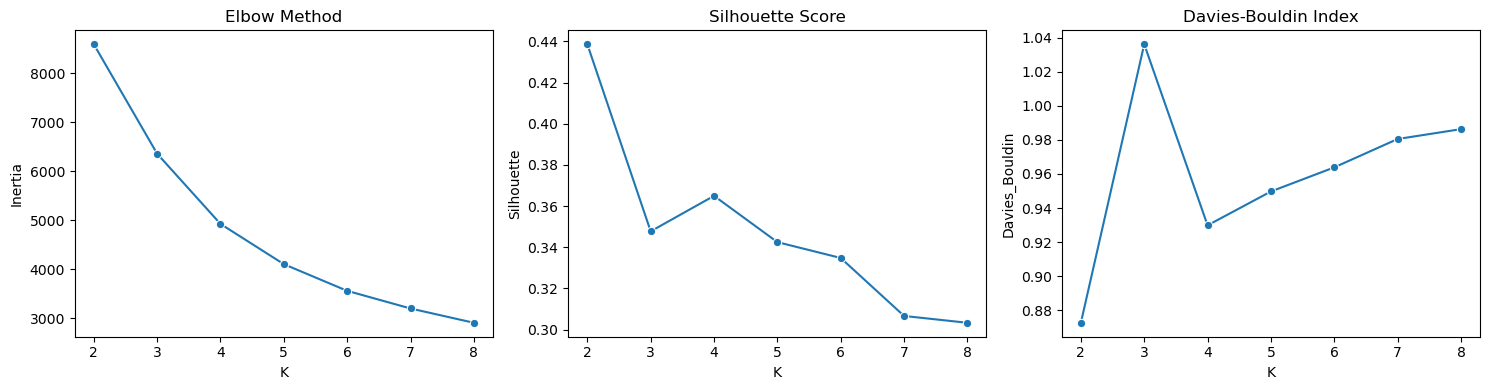

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.lineplot(
    data=cluster_results,
    x="K",
    y="Inertia",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("Elbow Method")

sns.lineplot(
    data=cluster_results,
    x="K",
    y="Silhouette",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Silhouette Score")

sns.lineplot(
    data=cluster_results,
    x="K",
    y="Davies_Bouldin",
    marker="o",
    ax=axes[2]
)
axes[2].set_title("Davies-Bouldin Index")

plt.tight_layout()
plt.show()

In [19]:
def create_cluster_profile(k):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    clustered = rfm.copy()
    clustered["Cluster"] = model.fit_predict(rfm_scaled)

    profile = (
        clustered
        .groupby("Cluster")
        .agg(
            Customers=("Customer ID", "count"),
            Median_Recency=("Recency", "median"),
            Median_Frequency=("Frequency", "median"),
            Median_Monetary=("Monetary", "median"),
            Mean_Recency=("Recency", "mean"),
            Mean_Frequency=("Frequency", "mean"),
            Mean_Monetary=("Monetary", "mean")
        )
    )

    profile["Customer_Percentage"] = (
        profile["Customers"] / len(clustered) * 100
    )

    return model, clustered, profile

In [20]:
model_k2, customers_k2, profile_k2 = create_cluster_profile(2)
model_k4, customers_k4, profile_k4 = create_cluster_profile(4)

print("K = 2 profile")
display(profile_k2.round(2))

print("K = 4 profile")
display(profile_k4.round(2))

K = 2 profile


,Customers,Median_Recency,Median_Frequency,Median_Monetary,Mean_Recency,Mean_Frequency,Mean_Monetary,Customer_Percentage
Cluster,,,,,,,,
0,3558,289.5,2.0,415.80,299.65,2.10,614.34,60.53
1,2320,24.0,8.0,2861.48,50.56,12.72,6546.97,39.47


K = 4 profile


,Customers,Median_Recency,Median_Frequency,Median_Monetary,Mean_Recency,Mean_Frequency,Mean_Monetary,Customer_Percentage
Cluster,,,,,,,,
0,1973,402.0,1.0,273.31,394.95,1.38,317.08,33.57
1,1250,24.0,3.0,734.12,28.30,3.05,857.49,21.27
2,1196,17.0,13.0,4986.12,27.71,19.28,10731.16,20.35
3,1459,186.0,4.0,1450.04,230.07,5.06,1948.50,24.82


### 3.3 Selected K-means model with four customer segments

In [21]:
selected_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = selected_kmeans.fit_predict(rfm_scaled)

selected_silhouette = silhouette_score(
    rfm_scaled,
    rfm["Cluster"]
)

selected_davies_bouldin = davies_bouldin_score(
    rfm_scaled,
    rfm["Cluster"]
)

print("Selected K:", 4)
print("Silhouette score:", round(selected_silhouette, 3))
print(
    "Davies-Bouldin index:",
    round(selected_davies_bouldin, 3)
)

Selected K: 4
Silhouette score: 0.365
Davies-Bouldin index: 0.93


In [22]:
cluster_names = {
    0: "Lapsed Low-Value",
    1: "Recent Regular",
    2: "High-Value Loyal",
    3: "At-Risk Valuable"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_names)

In [23]:
selected_profile = (
    rfm
    .groupby("Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Median_Recency=("Recency", "median"),
        Median_Frequency=("Frequency", "median"),
        Median_Monetary=("Monetary", "median")
    )
)

selected_profile["Customer_Percentage"] = (
    selected_profile["Customers"] / len(rfm) * 100
)

selected_profile = selected_profile.sort_values(
    "Median_Monetary",
    ascending=False
)

display(selected_profile.round(2))

,Customers,Median_Recency,Median_Frequency,Median_Monetary,Customer_Percentage
Segment,,,,,
High-Value Loyal,1196,17.0,13.0,4986.12,20.35
At-Risk Valuable,1459,186.0,4.0,1450.04,24.82
Recent Regular,1250,24.0,3.0,734.12,21.27
Lapsed Low-Value,1973,402.0,1.0,273.31,33.57


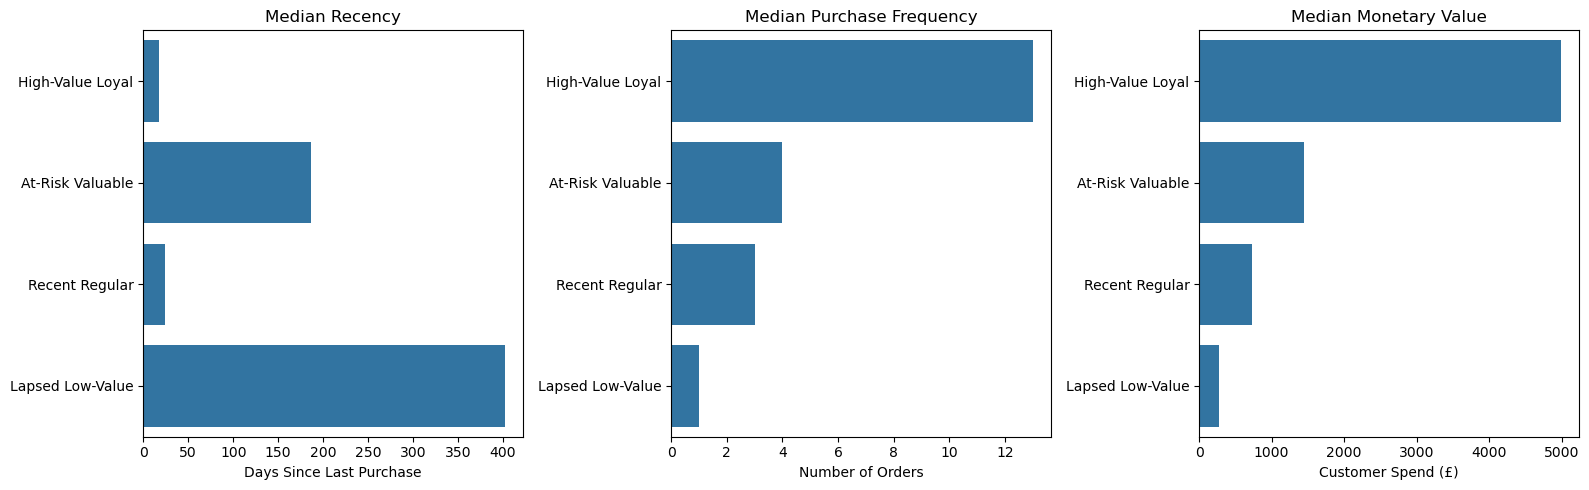

In [24]:
plot_data = selected_profile.reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(
    data=plot_data,
    x="Median_Recency",
    y="Segment",
    ax=axes[0]
)
axes[0].set_title("Median Recency")
axes[0].set_xlabel("Days Since Last Purchase")
axes[0].set_ylabel("")

sns.barplot(
    data=plot_data,
    x="Median_Frequency",
    y="Segment",
    ax=axes[1]
)
axes[1].set_title("Median Purchase Frequency")
axes[1].set_xlabel("Number of Orders")
axes[1].set_ylabel("")

sns.barplot(
    data=plot_data,
    x="Median_Monetary",
    y="Segment",
    ax=axes[2]
)
axes[2].set_title("Median Monetary Value")
axes[2].set_xlabel("Customer Spend (£)")
axes[2].set_ylabel("")

plt.tight_layout()
plt.savefig(
    "kmeans_customer_segments.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 4. Logistic Regression Interpretation and Visualisation

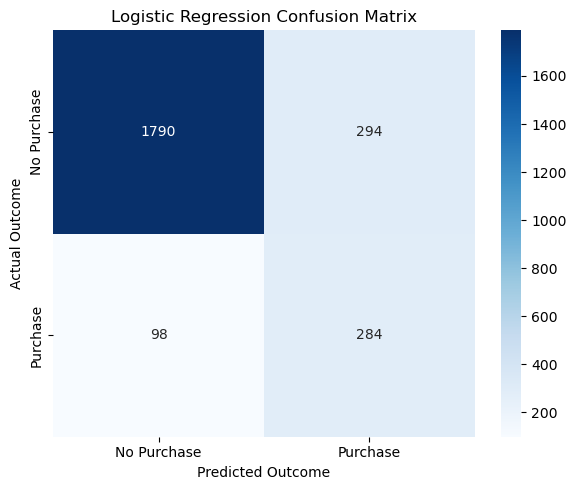

In [25]:
confusion = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.tight_layout()

plt.savefig(
    "logistic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    logistic_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": permutation_result.importances_mean,
    "Std": permutation_result.importances_std
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance.round(4))

,Feature,Importance,Std
8,PageValues,0.3885,0.0069
10,Month,0.0415,0.0057
7,ExitRates,0.0141,0.0032
14,TrafficType,0.0066,0.0026
5,ProductRelated_Duration,0.0014,0.0010
11,OperatingSystems,0.0013,0.0009
4,ProductRelated,0.0013,0.0008
13,Region,0.0007,0.0010
15,VisitorType,0.0004,0.0003
6,BounceRates,0.0004,0.0007


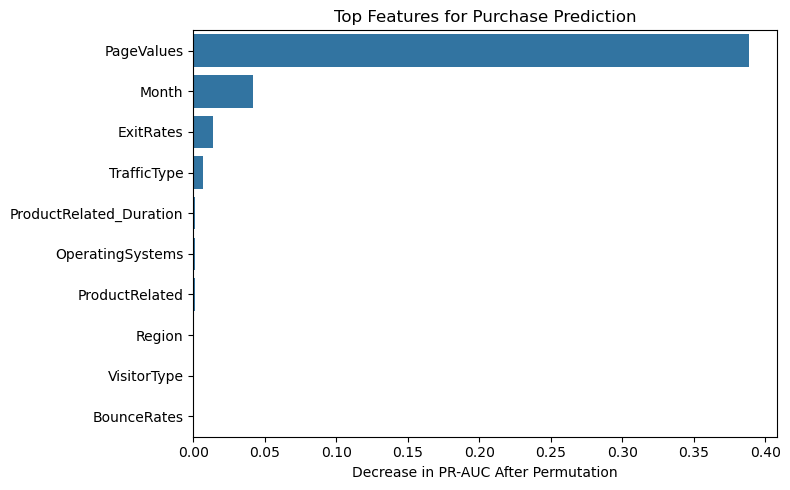

In [27]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Features for Purchase Prediction")
plt.xlabel("Decrease in PR-AUC After Permutation")
plt.ylabel("")
plt.tight_layout()

plt.savefig(
    "logistic_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
# Sensitivity test: remove PageValues

X_without_pagevalues = shoppers.drop(
    columns=["Revenue", "PageValues"]
)
y_without_pagevalues = shoppers["Revenue"].astype(int)

categorical_without_pagevalues = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

numeric_without_pagevalues = [
    column
    for column in X_without_pagevalues.columns
    if column not in categorical_without_pagevalues
]

X_train_no_page, X_test_no_page, y_train_no_page, y_test_no_page = (
    train_test_split(
        X_without_pagevalues,
        y_without_pagevalues,
        test_size=0.20,
        stratify=y_without_pagevalues,
        random_state=42
    )
)

preprocessor_no_page = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_without_pagevalues
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_without_pagevalues
        )
    ]
)

logistic_no_page = Pipeline(
    steps=[
        ("preprocessing", preprocessor_no_page),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_no_page.fit(X_train_no_page, y_train_no_page)

y_pred_no_page = logistic_no_page.predict(X_test_no_page)
y_prob_no_page = logistic_no_page.predict_proba(
    X_test_no_page
)[:, 1]

print(classification_report(
    y_test_no_page,
    y_pred_no_page,
    digits=3
))

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test_no_page, y_prob_no_page), 3)
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test_no_page,
            y_prob_no_page
        ),
        3
    )
)

display(pd.DataFrame(
    confusion_matrix(y_test_no_page, y_pred_no_page),
    index=["Actual: No Purchase", "Actual: Purchase"],
    columns=["Predicted: No Purchase", "Predicted: Purchase"]
))

              precision    recall  f1-score   support

           0      0.930     0.608     0.735      2084
           1      0.259     0.749     0.385       382

    accuracy                          0.630      2466
   macro avg      0.594     0.678     0.560      2466
weighted avg      0.826     0.630     0.681      2466

ROC-AUC: 0.735
PR-AUC: 0.321


,Predicted: No Purchase,Predicted: Purchase
Actual: No Purchase,1267,817
Actual: Purchase,96,286


In [30]:
from sklearn.metrics import recall_score, precision_score

In [31]:
model_comparison = pd.DataFrame({
    "Model": [
        "With PageValues",
        "Without PageValues"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_probability),
        roc_auc_score(y_test_no_page, y_prob_no_page)
    ],
    "PR_AUC": [   “PR_AUC”：[   “PR_AUC”：[   “PR_AUC”：[   “PR_AUC”：[   “PR_AUC”：[   “PR_AUC”：[   “PR_AUC”：[   “PR_AUC”：[
        average_precision_score(y_test, y_probability),average_precision_score(y_test, y_probability)average_precision_score(y_test, y_probability)average_precision_score(y_test, y_probability)average_precision_score(y_test, y_probability)average_precision_score(y_test, y_probability)average_precision_score(y_test, y_probability)average_precision_score(y_test, y_probability)average_precision_score(y_test, y_probability)
        average_precision_score(  
            y_test_no_page,   y_test_no_page，   y_test_no_page，   y_test_no_page，   y_test_no_page，   y_test_no_page，   y_test_no_page，   y_test_no_page，   y_test_no_page，
            y_prob_no_page
        )
    ],
    "Purchase_Recall": [   
        recall_score(y_test, y_pred),
        recall_score(y_test_no_page, y_pred_no_page)
    ],
    "Purchase_Precision": [ 
        precision_score(y_test, y_pred),precision_score(y_test, y_pred)，precision_score(y_test, y_pred)，precision_score(y_test, y_pred)，
        precision_score(y_test_no_page, y_pred_no_page)
    ]
})

display(model_comparison.round(3))

,Model,ROC_AUC,PR_AUC,Purchase_Recall,Purchase_Precision
0,With PageValues,0.893,0.622,0.743,0.491
1,Without PageValues,0.735,0.321,0.749,0.259
